In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon, friedmanchisquare

plt.rcParams["figure.figsize"] = (8,4)
plt.rcParams["axes.grid"] = True


In [2]:

df = pd.read_json("../results/results.jsonl", orient="records", lines=True)


solver = df[df.alg=="solver"][["graph","value"]].set_index("graph").value


df = df.join(solver, on="graph", rsuffix="_opt")
df["gap"] = (df["value_opt"] - df["value"]) / df["value_opt"]

df.head(8)


,alg,graph,value,time,value_opt,gap
0,bruteforce,n6_p0.5,43,0.000355,43,0.000000
1,solver,n6_p0.5,43,0.006412,43,0.000000
2,gw_t5,n6_p0.5,43,0.000160,43,0.000000
3,gw_t10,n6_p0.5,38,0.000130,43,0.116279
4,gw_t20,n6_p0.5,43,0.000258,43,0.000000
5,qaoa_p1_r0,n6_p0.5,23,0.010171,43,0.465116
6,qaoa_p1_r1,n6_p0.5,20,0.010787,43,0.534884
7,qaoa_p1_r2,n6_p0.5,19,0.006760,43,0.558140


In [3]:
summary = (
    df
    .groupby(["graph","alg"])
    .agg(mean_value=("value","mean"),
         std_value =("value","std"),
         mean_time = ("time","mean"),
         std_time  = ("time","std"))
    .reset_index()
)
summary


,graph,alg,mean_value,std_value,mean_time,std_time
0,n6_p0.5,bruteforce,43.0,NaN,0.000355,NaN
1,n6_p0.5,gw_t10,38.0,NaN,0.000130,NaN
2,n6_p0.5,gw_t20,43.0,NaN,0.000258,NaN
3,n6_p0.5,gw_t5,43.0,NaN,0.000160,NaN
4,n6_p0.5,qaoa_p1_r0,23.0,NaN,0.010171,NaN
5,n6_p0.5,qaoa_p1_r1,20.0,NaN,0.010787,NaN
6,n6_p0.5,qaoa_p1_r2,19.0,NaN,0.006760,NaN
7,n6_p0.5,qaoa_p1_r3,29.0,NaN,0.006724,NaN
8,n6_p0.5,qaoa_p1_r4,37.0,NaN,0.006036,NaN
9,n6_p0.5,qaoa_p1_r5,31.0,NaN,0.006198,NaN


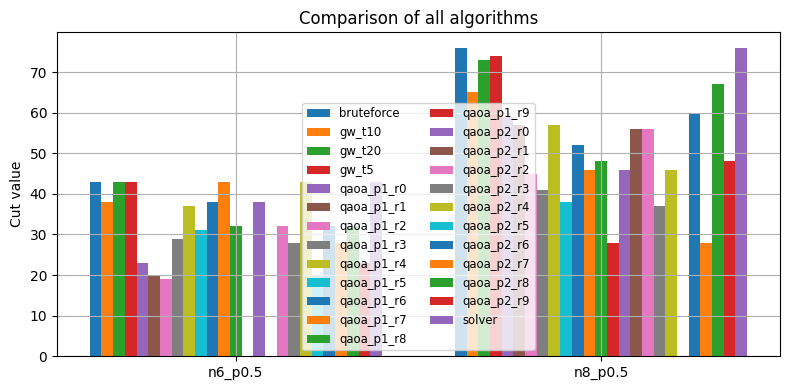

In [4]:
graphs = summary.graph.unique()
algs   = summary.alg.unique()
x = np.arange(len(graphs))
w = 0.8/len(algs)

fig, ax = plt.subplots()
for i,a in enumerate(algs):
    grp = summary[summary.alg==a].set_index("graph")
    m = [grp.loc[g,"mean_value"] for g in graphs]
    s = [grp.loc[g,"std_value"]  for g in graphs]
    ax.bar(x + i*w - (len(algs)-1)*w/2, m, w, yerr=s, capsize=4, label=a)

ax.set_xticks(x)
ax.set_xticklabels(graphs)
ax.set_ylabel("Cut value")
ax.set_title("Comparison of all algorithms")
ax.legend(ncol=2, fontsize="small")
fig.tight_layout()


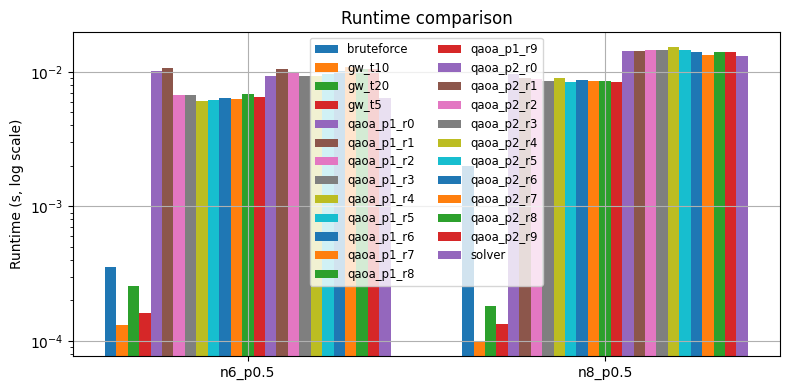

In [5]:
fig, ax = plt.subplots()
for i,a in enumerate(algs):
    grp = summary[summary.alg==a].set_index("graph")
    m = [grp.loc[g,"mean_time"] for g in graphs]
    s = [grp.loc[g,"std_time"]  for g in graphs]
    ax.bar(x + i*w - (len(algs)-1)*w/2, m, w, yerr=s, capsize=4, label=a)

ax.set_xticks(x)
ax.set_xticklabels(graphs)
ax.set_yscale("log")
ax.set_ylabel("Runtime (s, log scale)")
ax.set_title("Runtime comparison")
ax.legend(ncol=2, fontsize="small")
fig.tight_layout()


In [6]:
print("Wilcoxon signed‐rank: GW_t20 vs QAOA_p2")
for g in graphs:
    wv = df[(df.graph==g)&(df.alg=="gw_t20")]["value"]
    qv = df[(df.graph==g)&(df.alg.str.startswith("qaoa_p2"))]["value"]
    if len(wv)>1 and len(qv)>1:
        p = wilcoxon(wv, qv).pvalue
        print(f" {g}: p={p:.3g}")
    else:
        print(f" {g}: skip (need ≥2 samples)")


Wilcoxon signed‐rank: GW_t20 vs QAOA_p2
 n6_p0.5: skip (need ≥2 samples)
 n8_p0.5: skip (need ≥2 samples)


In [7]:
# pivot to algorithms×graphs of mean values
pt = summary.pivot(index="alg", columns="graph", values="mean_value")
stat, p = friedmanchisquare(*(pt.loc[a] for a in pt.index))
print("Friedman χ² across all algorithms:", f"p={p:.3g}")


Friedman χ² across all algorithms: p=0.0442
